Jax and torch do not work in the same environment, so run with a python 3.9.17 kernel with gWOT_requirements.txt installed.

In [1]:
import sklearn
import gwot
import torch
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt

In [2]:
adata = sc.read_h5ad('./time_course_methods_comp.h5ad')
adata_keys = {'time_key': 'chronological_age', 
              'embed_key': 'X_pca',
              'growth_rate_key': 'growth_rate',
              }

<Axes: title={'center': 'chronological_age'}, xlabel='PC1', ylabel='PC2'>

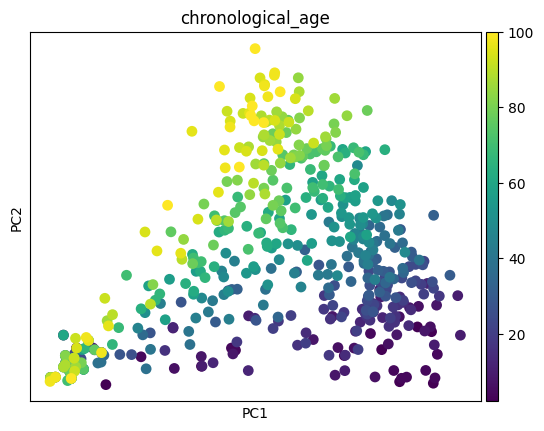

In [3]:
sc.pl.pca(adata, color = 'chronological_age', show = False)

In [4]:
def get_C_mean(adata_s, t, t_next = None, mode = "tr"):
    if mode == "tr":
        C = sklearn.metrics.pairwise_distances(adata_s.obsm['X_pca'][adata_s.obs[adata_keys['time_key']]== t, :], adata_s.obsm['X_pca'][adata_s.obs[adata_keys['time_key']] == t_next, :], metric = 'sqeuclidean')
    elif mode == "self":
        C = sklearn.metrics.pairwise_distances(adata_s.obsm['X_pca'][adata_s.obs[adata_keys['time_key']] == t, :], adata_s.obsm['X_pca'][adata_s.obs[adata_keys['time_key']] == t, :], metric = 'sqeuclidean')
    return np.mean(C)


device = 'cpu' 
torch.set_default_tensor_type(torch.DoubleTensor)

adata_s = adata

t_idx = np.zeros(adata_s.X.shape[0], dtype = np.int64)

t_map = np.sort(adata_s.obs[adata_keys['time_key']].unique())
age_masks = [adata_s.obs[adata_keys['time_key']] == t for t in t_map]
T = len(age_masks)
for i in range(0, T):
    t_idx[age_masks[i]] = i

c_means = np.array([get_C_mean(adata_s, t_map[i], t_next = t_map[i+1], mode = "tr") for i in range(0, len(t_map[:-1]))])
c_means_self = np.array([get_C_mean(adata_s, t, mode = "self") for t in t_map])

dt = np.array([t_map[i+1] - t_map[i] for i in range(0, len(t_map)-1)]) 
eps_eff = 0.1
eps_df = 0.01
lamda_reg = 0.00215
import gwot.ts
tsdata = gwot.ts.TimeSeries(x = np.asarray(adata_s.X, dtype = np.float64),  
                dt = dt/dt.sum(), 
                t_idx = t_idx, 
                D = eps_eff)


g = (tsdata.dt[0]*torch.tensor(adata.obs['growth_rate'].to_numpy()).repeat(tsdata.T, 1)).exp()
m = np.power(g.mean(), np.arange(0, tsdata.T))

import gwot.models
model_growth = gwot.models.OTModel(tsdata, lamda_reg = lamda_reg,
          eps_df = eps_df*torch.ones(tsdata.T).to(device), 
          m = m.to(device), 
          g = g.to(device),
          kappa = None, 
          growth_constraint="exact", 
          pi_0 = "uniform",
          use_keops = False,
)


sol = model_growth.solve_lbfgs(steps = 20, max_iter = 50, lr = 1, history_size = 50, line_search_fn = 'strong_wolfe', factor = 2, tol = 1e-5, retry_max = 0)

/home/cole/coding/global-stationaryOT/extra/gWOT_comparison/.torch_venv/lib/python3.9/site-packages/torch/__init__.py:1264: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /pytorch/torch/csrc/tensor/python_tensor.cpp:434.)
  _C._set_default_tensor_type(t)


[KeOps] Compiling cuda jit compiler engine ... 
[KeOps] Warning : There were warnings or errors :
/usr/bin/ld: cannot find -lnvrtc: No such file or directory
collect2: error: ld returned 1 exit status

OK
[pyKeOps] Compiling nvrtc binder for python ... 
[KeOps] Warning : There were warnings or errors :
/usr/bin/ld: cannot find -lnvrtc: No such file or directory
collect2: error: ld returned 1 exit status

OK


/home/cole/coding/global-stationaryOT/extra/gWOT_comparison/.torch_venv/lib/python3.9/site-packages/gwot/models.py:296: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4421.)
  model.eps_df[i] * torch.exp(u/model.eps_df[i]).T @ (model.K_ij_df[i] @ torch.exp(v/model.eps_df[i]))


Iteration =  0  Dual obj =  -0.4855686529600449  Primal_obj =  43.43863664037228  Gap =  43.92420529333233 Sum =  52.212934798758596
Iteration =  1  Dual obj =  0.012378271828129984  Primal_obj =  0.04340972381085581  Gap =  0.031031451982725826 Sum =  0.9016782837018577
Iteration =  2  Dual obj =  0.04452611509533402  Primal_obj =  0.053473397700519995  Gap =  0.008947282605185972 Sum =  1.057129831801327
Iteration =  3  Dual obj =  0.06086232404055029  Primal_obj =  0.06570313087405194  Gap =  0.004840806833501653 Sum =  1.1065469794979075
Iteration =  4  Dual obj =  0.06821912976403516  Primal_obj =  0.06996554750095399  Gap =  0.0017464177369188316 Sum =  1.0477697323143134
Iteration =  5  Dual obj =  0.0704084975848286  Primal_obj =  0.06972251645740007  Gap =  -0.0006859811274285282 Sum =  1.0287482100324272
Iteration =  6  Dual obj =  0.07094502610510747  Primal_obj =  0.07050292106780118  Gap =  -0.00044210503730629513 Sum =  0.9915613755159185
Iteration =  7  Dual obj =  0.071

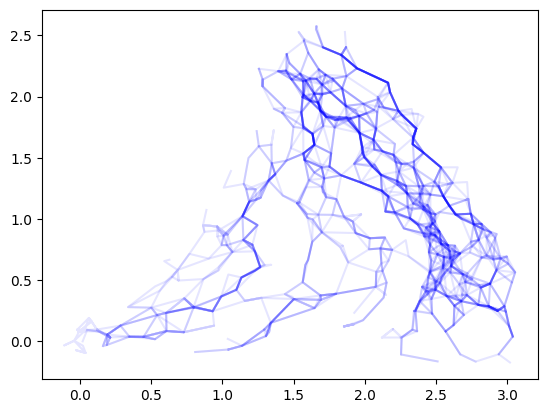

In [5]:

N_paths = 100
import gwot.bridgesampling as bs
with torch.no_grad():
    paths_growth = bs.sample_paths(None, N = N_paths, coord = True, x_all = [adata_s.X, ]*T, 
                        get_gamma_fn = lambda i : model_growth.get_coupling_reg(i, K = model_growth.get_K(i)).cpu(), num_couplings = T-1)
    
plt.plot(paths_growth[:, :, 0].T, paths_growth[:, :, 1].T, color = 'blue', alpha = 0.1)
plt.show()

In [6]:
np.save('./gWOT_traj.npy', paths_growth)